<a href="https://colab.research.google.com/github/luigiselmi/climate/blob/main/ecmwf/earthkit_meteorological_computations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Earthkit 1.0 - Meteorological Computations

In [1]:
#!pip install -q earthkit

## 1. Getting the data

In [4]:
import earthkit.data as ekd

ds = ekd.from_source("sample", "tquv_pl_2x2.grib").to_fieldlist()
ds.head(6)

tquv_pl_2x2.grib:   0%|          | 0.00/771k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
1,q,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
2,u,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
3,v,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
4,t,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll
5,q,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll


## 2. Computing potential temperature

In [6]:
from earthkit.meteo.thermo.fieldlist import potential_temperature

# select temperature fields
t = ds.sel({"parameter.variable": "t"})

ds_pt = potential_temperature(t)
ds_pt.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
1,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll
2,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,700,pressure,0,regular_ll
3,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,500,pressure,0,regular_ll
4,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,400,pressure,0,regular_ll
5,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,300,pressure,0,regular_ll


In [7]:
ds_pt.to_target("file", "_pt_res.grib")

# read back saved data and check first 2 fields
ds_pt = ekd.from_source("file", "_pt_res.grib").to_fieldlist()
ds_pt.head(2)

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
1,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


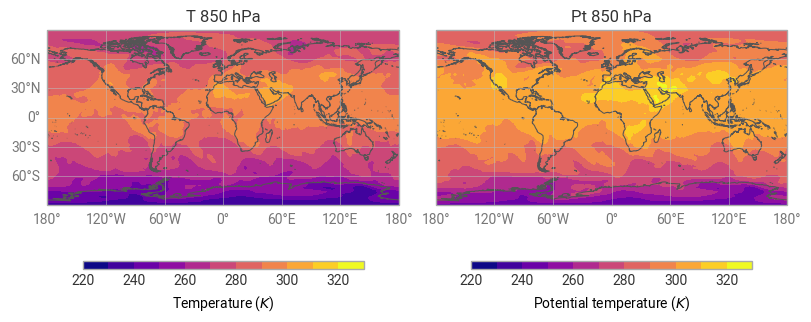

In [8]:
import earthkit.plots as ekp

figure = ekp.Figure(rows=1, columns=2)

level = 850
t_style = ekp.styles.Style(units="K", levels=list(range(220, 340, 10)))

subplot = figure.add_map(0, 0)
subplot.contourf(t.sel({"vertical.level": level}), style=t_style)
subplot.title("{shortName} {level} hPa")
subplot.legend()

subplot = figure.add_map(0, 1)
subplot.contourf(ds_pt.sel({"vertical.level": level}), style=t_style)
subplot.title("{shortName} {level} hPa")
subplot.legend()

figure.coastlines()
figure.gridlines()

figure.show()

## 3. Computing the wind speed

In [9]:
ds = ekd.from_source("sample", "tquv_pl_2x2.grib").to_fieldlist()

tquv_pl_2x2.grib:   0%|          | 0.00/771k [00:00<?, ?B/s]

In [11]:
from earthkit.meteo.wind.fieldlist import speed

# select the u and v fields. We assume here they
# are valid for the same set of levels
u = ds.sel({"parameter.variable": "u"})
v = ds.sel({"parameter.variable": "v"})

ds_ws = speed(u, v)
ds_ws.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
1,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll
2,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,700,pressure,0,regular_ll
3,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,500,pressure,0,regular_ll
4,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,400,pressure,0,regular_ll
5,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,300,pressure,0,regular_ll


In [12]:
ds_ws.to_target("file", "_ws_res.grib")

# read back saved data and check first 2 fields
ds_ws = ekd.from_source("file", "_ws_res.grib").to_fieldlist()
ds_ws.head(2)

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
1,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll


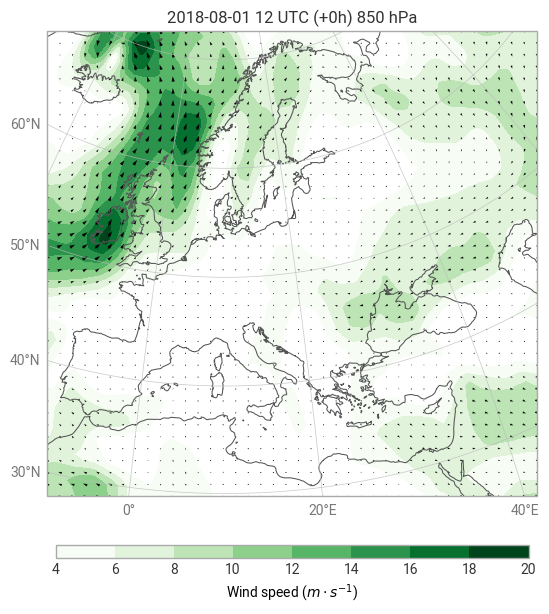

In [13]:
level = 850

chart = ekp.Map(domain="Europe", size=(6, 6))
chart.contourf(
    ds_ws.sel({"vertical.level": level}),
    units="m s-1",
    colors="Greens",
    levels=list(range(4, 22, 2)),
    alpha=1,
)
chart.quiver(u=u.sel({"vertical.level": level}), v=v.sel({"vertical.level": level}))
chart.coastlines()
chart.gridlines()
chart.legend()
chart.title(("{time:%Y-%m-%d %H} UTC (+{lead_time}h) {level} hPa"))

chart.show()